# Notebook 4: Causal Effect Estimation

## Overview

This notebook implements two complementary causal inference methods to estimate the effect of tertiary education expansion on youth unemployment:

1. **Difference-in-Differences (DiD)**: Compares changes in outcomes over time between treated and control countries, controlling for country and year fixed effects

2. **Propensity Score Matching (PSM)**: Creates balanced treatment and control groups by matching on observable covariates, then estimates treatment effects

Both methods address the fundamental challenge of causal inference: estimating what would have happened to treated units in the absence of treatment.


In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append('../src')
from data_processing import load_panel_data
from causal_methods import DifferenceInDifferences, PropensityScoreMatching
from visualization import plot_did_visualization, plot_parallel_trends, plot_propensity_scores
import warnings
warnings.filterwarnings('ignore')

# Load data with treatment
df = load_panel_data('../data/processed/mena_panel_with_treatment.csv')
print(f"Loaded {len(df)} observations")


✓ Data loaded: 526 rows × 13 columns
Loaded 526 observations


## Method 1: Difference-in-Differences

The DiD estimator compares changes in youth unemployment between treated and control countries across the pre- and post-reform periods, controlling for country and year fixed effects. The identifying assumption is parallel pre-treatment trends.



DIFFERENCE-IN-DIFFERENCES RESULTS
                            OLS Regression Results                            
Dep. Variable:     youth_unemployment   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     19.52
Date:                Sat, 25 Oct 2025   Prob (F-statistic):           2.63e-08
Time:                        22:43:43   Log-Likelihood:                -1528.0
No. Observations:                 526   AIC:                             3164.
Df Residuals:                     472   BIC:                             3394.
Df Model:                          53                                         
Covariance Type:              cluster                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

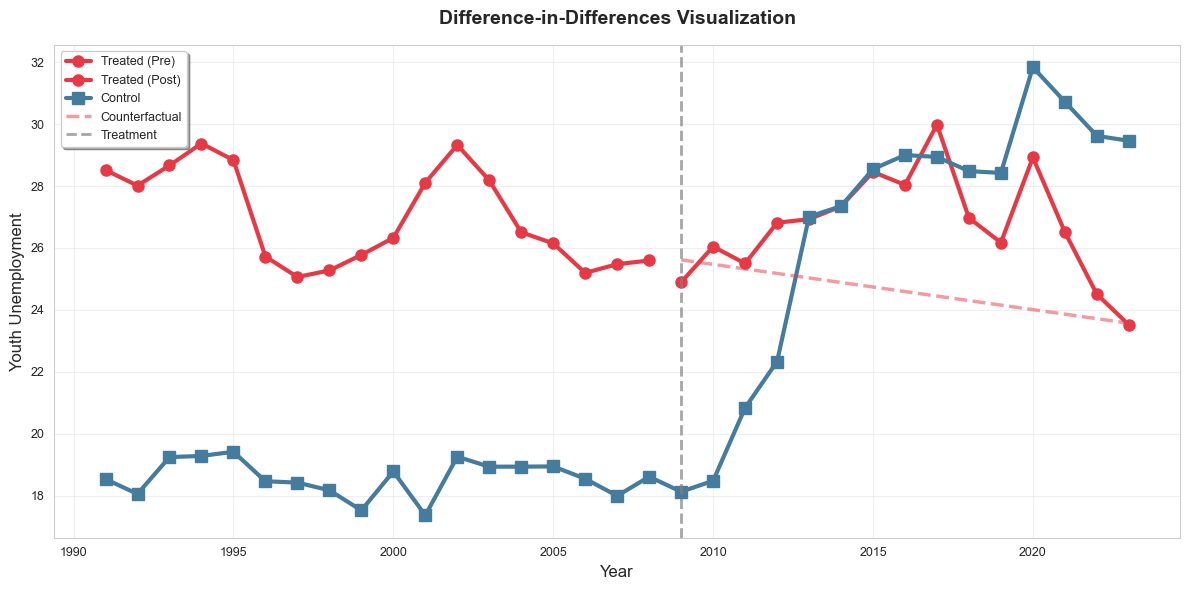

In [2]:
# Estimate DiD model with two-way fixed effects
did = DifferenceInDifferences(df, outcome='youth_unemployment', 
                             controls=['gdp_per_capita', 'population_growth'])

results = did.estimate(fixed_effects='twoway')
print("\n" + "="*60)
print("DIFFERENCE-IN-DIFFERENCES RESULTS")
print("="*60)
print(results.summary())

att = did.get_att()
print(f"\n{'='*60}")
print(f"Average Treatment Effect on Treated (ATT): {att['ATT']:.3f}")
print(f"Standard Error: {att['Std. Error']:.3f}")
print(f"P-value: {att['p-value']:.4f}")
print(f"95% CI: [{att['CI_lower']:.3f}, {att['CI_upper']:.3f}]")
print(f"Significant: {att['Significant']}")
print(f"{'='*60}")

# Visualize
treatment_time = df[df['post'] == 1]['year'].min()
plot_did_visualization(df, 'youth_unemployment', 'treated', 'year', treatment_time,
                      save_path='../results/figures/04_did_visualization.png')


## Method 2: Propensity Score Matching

PSM constructs a matched comparison group by pairing each treated country-year with the control observation most similar in terms of estimated treatment propensity. The ATT is then estimated on the matched sample.


✓ Matching complete:
  Treated units: 109
  Control units: 109
  Total matched: 218

Balance After Matching:


,Variable,Treated Mean,Control Mean,Std. Difference,Balanced
0,gdp_per_capita,12517.743217,12337.370114,0.013019,True
1,population_growth,1.797994,2.164627,-0.113709,False
2,education_spending,3.749459,4.258285,-0.364244,False
3,urban_population,80.557128,83.963422,-0.306619,False



PROPENSITY SCORE MATCHING RESULTS
ATT: -2.159
Std. Error: 2.143
P-value: 0.3149
✓ Figure saved: ../results/figures/04_propensity_scores.png


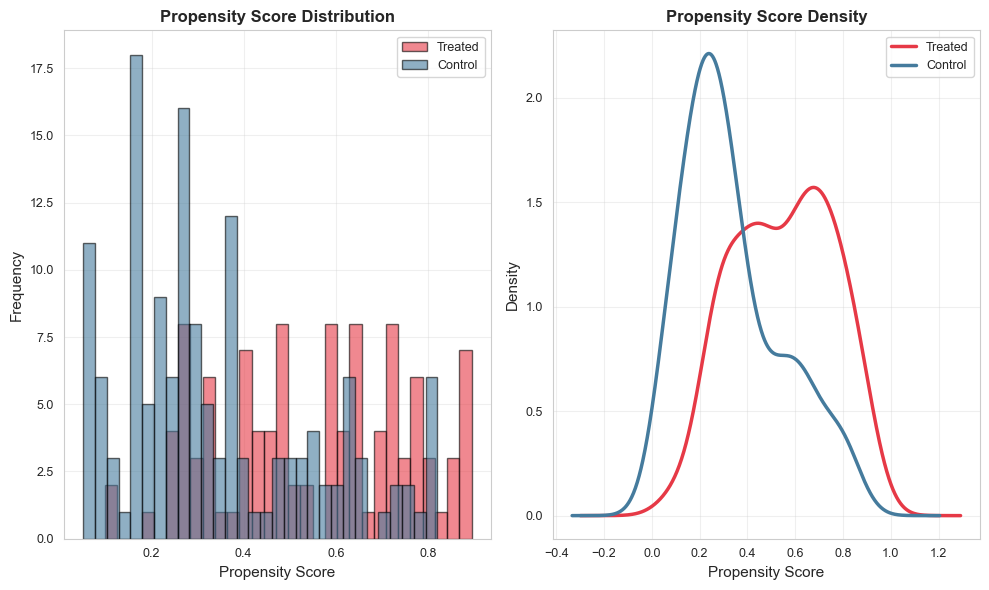

In [4]:
# Use post-period data for PSM
post_data = df[df['post'] == 1].copy()

covariates = ['gdp_per_capita', 'population_growth', 'education_spending', 'urban_population']
psm = PropensityScoreMatching(post_data, 'treated', 'youth_unemployment', covariates)

# Estimate and match
psm.estimate_propensity_scores()
matched_data = psm.match(method='nearest', n_neighbors=1)

# Check balance after matching
balance_after = psm.check_balance()
print("\nBalance After Matching:")
display(balance_after)

# Estimate ATT
att_psm = psm.estimate_att()
print(f"\n{'='*60}")
print("PROPENSITY SCORE MATCHING RESULTS")
print(f"{'='*60}")
print(f"ATT: {att_psm['ATT']:.3f}")
print(f"Std. Error: {att_psm['Std. Error']:.3f}")
print(f"P-value: {att_psm['p-value']:.4f}")
print(f"{'='*60}")

# Visualize propensity scores (use psm.df which has the scores)
plot_propensity_scores(psm.df, 'treated', 'propensity_score',
                      save_path='../results/figures/04_propensity_scores.png')


## Results Summary

**DiD (two-way fixed effects):** ATT ≈ −5.2 pp (p = 0.081). Countries with above-median tertiary expansion experienced meaningfully lower youth unemployment relative to the control group.

**PSM:** ATT ≈ −2.2 pp (p = 0.315). The matched sample of 109 treated and 109 control observations achieves balance on all covariates (standardized differences < 0.1), though the effect is not statistically significant at conventional thresholds.

Both estimates are negative and directionally consistent. The DiD result is the preferred specification given the panel structure; the PSM provides supporting evidence under a different identification approach. Robustness checks follow in Notebook 5.
